# Project 4: Feature Engineering on Restaurant Tips Dataset

**Building on Project 2: Data Value Chain Analysis**

---

**Student:** VIHANGA  
**Program:** Master's in Computer Science  
**Institution:** Transport and Telecommunication Institute, Latvia  
**Course:** Big Data 
**Date:** November 2025

---

## Project Overview

This project applies comprehensive feature engineering techniques to the restaurant tips dataset previously analyzed in Project 2. We will systematically apply various feature engineering methods and evaluate their impact on predictive model performance.



## 1. Environment Setup and Data Loading

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.preprocessing import PolynomialFeatures, PowerTransformer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, RFE
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("PROJECT 4: FEATURE ENGINEERING ON RESTAURANT TIPS DATASET")
print("="*80)
print("\n✅ All libraries imported successfully")
print("📊 Building on insights from Project 2: Data Value Chain Analysis")

PROJECT 4: FEATURE ENGINEERING ON RESTAURANT TIPS DATASET

✅ All libraries imported successfully
📊 Building on insights from Project 2: Data Value Chain Analysis


## 2. Data Acquisition and Exploration

In [2]:
print("\n" + "="*80)
print("SECTION 1: DATA ACQUISITION")
print("="*80)

# Load dataset from Seaborn
DATA_URL = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'

try:
    df_raw = pd.read_csv(DATA_URL)
    print(f"\n✅ Data loaded successfully from: {DATA_URL}")
    print(f"   Shape: {df_raw.shape}")
    print(f"   Memory Usage: {df_raw.memory_usage(deep=True).sum() / 1024:.2f} KB")
except Exception as e:
    print(f"❌ Error loading data: {e}")
    raise

# Display basic information
print("\n📊 Dataset Overview:")
print(df_raw.info())

print("\n📈 Statistical Summary:")
print(df_raw.describe())

print("\n🔍 First Few Records:")
display(df_raw.head(10))

print("\n🎯 Target Variable (tip) Distribution:")
print(df_raw['tip'].describe())


SECTION 1: DATA ACQUISITION

✅ Data loaded successfully from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv
   Shape: (244, 7)
   Memory Usage: 64.00 KB

📊 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None

📈 Statistical Summary:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.00

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2



🎯 Target Variable (tip) Distribution:
count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64


In [3]:
# Data quality check
print("\n📋 Data Quality Assessment:")
print(f"   Missing Values: {df_raw.isnull().sum().sum()}")
print(f"   Duplicate Rows: {df_raw.duplicated().sum()}")
print(f"   Data Types:")
for col, dtype in df_raw.dtypes.items():
    print(f"      {col}: {dtype}")

# Check for any anomalies
print("\n🔍 Anomaly Detection:")
print(f"   Negative tips: {(df_raw['tip'] < 0).sum()}")
print(f"   Negative bills: {(df_raw['total_bill'] < 0).sum()}")
print(f"   Zero tips: {(df_raw['tip'] == 0).sum()}")
print(f"   Party size range: {df_raw['size'].min()} to {df_raw['size'].max()}")


📋 Data Quality Assessment:
   Missing Values: 0
   Duplicate Rows: 1
   Data Types:
      total_bill: float64
      tip: float64
      sex: object
      smoker: object
      day: object
      time: object
      size: int64

🔍 Anomaly Detection:
   Negative tips: 0
   Negative bills: 0
   Zero tips: 0
   Party size range: 1 to 6


## 3. Baseline Model Performance

Before applying feature engineering, we establish baseline performance with minimal preprocessing.

In [4]:
print("\n" + "="*80)
print("SECTION 2: BASELINE MODEL PERFORMANCE")
print("="*80)

# Prepare baseline features - only numerical column (total_bill and size)
# Simple label encoding for categorical variables
df_baseline = df_raw.copy()

# Encode categorical variables with simple label encoding
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_day = LabelEncoder()
le_time = LabelEncoder()

df_baseline['sex_encoded'] = le_sex.fit_transform(df_baseline['sex'])
df_baseline['smoker_encoded'] = le_smoker.fit_transform(df_baseline['smoker'])
df_baseline['day_encoded'] = le_day.fit_transform(df_baseline['day'])
df_baseline['time_encoded'] = le_time.fit_transform(df_baseline['time'])

# Select features and target
X_baseline = df_baseline[['total_bill', 'size', 'sex_encoded', 'smoker_encoded', 
                           'day_encoded', 'time_encoded']]
y = df_baseline['tip']

# Split data
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_baseline, y, test_size=0.2, random_state=42
)

print(f"\n📊 Baseline Feature Set:")
print(f"   Features: {list(X_baseline.columns)}")
print(f"   Number of features: {X_baseline.shape[1]}")
print(f"   Training samples: {X_train_base.shape[0]}")
print(f"   Test samples: {X_test_base.shape[0]}")


SECTION 2: BASELINE MODEL PERFORMANCE

📊 Baseline Feature Set:
   Features: ['total_bill', 'size', 'sex_encoded', 'smoker_encoded', 'day_encoded', 'time_encoded']
   Number of features: 6
   Training samples: 195
   Test samples: 49


In [5]:
# Train baseline models
print("\n🤖 Training Baseline Models...")

# Linear Regression
lr_baseline = LinearRegression()
lr_baseline.fit(X_train_base, y_train)
y_pred_lr_base = lr_baseline.predict(X_test_base)

# Random Forest
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_base, y_train)
y_pred_rf_base = rf_baseline.predict(X_test_base)

# Gradient Boosting
gb_baseline = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_baseline.fit(X_train_base, y_train)
y_pred_gb_base = gb_baseline.predict(X_test_base)

print("✅ Baseline models trained successfully")


🤖 Training Baseline Models...
✅ Baseline models trained successfully



📊 Baseline Model Performance:
                   R² Score    RMSE     MAE
Linear Regression    0.4441  0.8336  0.6704
Random Forest        0.2212  0.9867  0.7801
Gradient Boosting    0.3566  0.8968  0.7286


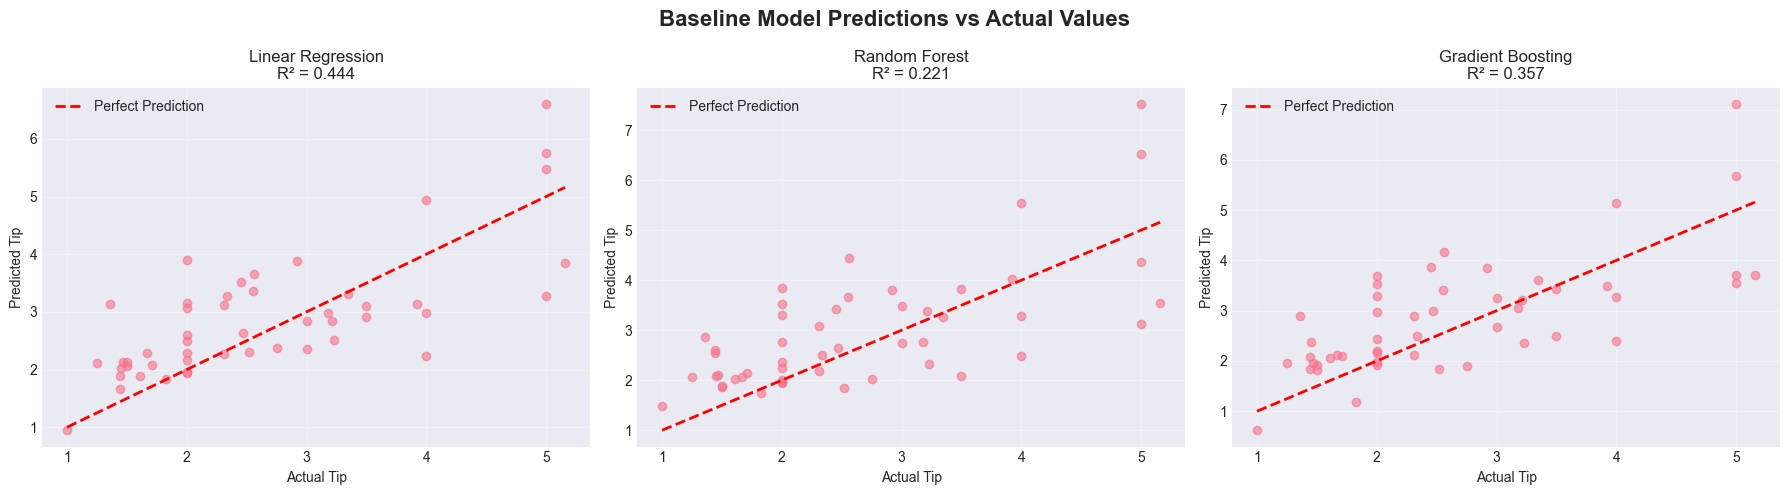

In [ ]:
# Evaluate baseline models
baseline_results = {
    'Linear Regression': {
        'R² Score': r2_score(y_test, y_pred_lr_base),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr_base)),
        'MAE': mean_absolute_error(y_test, y_pred_lr_base)
    },
    'Random Forest': {
        'R² Score': r2_score(y_test, y_pred_rf_base),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf_base)),
        'MAE': mean_absolute_error(y_test, y_pred_rf_base)
    },
    'Gradient Boosting': {
        'R² Score': r2_score(y_test, y_pred_gb_base),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_gb_base)),
        'MAE': mean_absolute_error(y_test, y_pred_gb_base)
    }
}

baseline_df = pd.DataFrame(baseline_results).T
print("\n📊 Baseline Model Performance:")
print(baseline_df.round(4))

# Visualize baseline predictions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Baseline Model Predictions vs Actual Values', fontsize=16, fontweight='bold')

models = [
    ('Linear Regression', y_pred_lr_base),
    ('Random Forest', y_pred_rf_base),
    ('Gradient Boosting', y_pred_gb_base)
]

for idx, (name, predictions) in enumerate(models):
    axes[idx].scatter(y_test, predictions, alpha=0.6)
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                   'r--', lw=2, label='Perfect Prediction')
    axes[idx].set_xlabel('Actual Tip')
    axes[idx].set_ylabel('Predicted Tip')
    axes[idx].set_title(f'{name}\nR² = {baseline_results[name]["R² Score"]:.3f}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Comprehensive Feature Engineering

We now apply systematic feature engineering techniques to improve model performance.

### 4.1 One-Hot Encoding for Categorical Variables

In [7]:
print("\n" + "="*80)
print("SECTION 3: COMPREHENSIVE FEATURE ENGINEERING")
print("="*80)

# Create a copy for feature engineering
df_fe = df_raw.copy()

print("\n[3.1] One-Hot Encoding for Categorical Variables")

# One-hot encode all categorical variables
df_fe = pd.get_dummies(df_fe, columns=['sex', 'smoker', 'day', 'time'], 
                        prefix=['sex', 'smoker', 'day', 'time'], drop_first=False)

print(f"   Original shape: {df_raw.shape}")
print(f"   After one-hot encoding: {df_fe.shape}")
print(f"   New columns added: {df_fe.shape[1] - df_raw.shape[1]}")
print(f"   \n   Categorical columns encoded:")
print(f"      • sex (2 categories)")
print(f"      • smoker (2 categories)")
print(f"      • day (4 categories)")
print(f"      • time (2 categories)")


SECTION 3: COMPREHENSIVE FEATURE ENGINEERING

[3.1] One-Hot Encoding for Categorical Variables
   Original shape: (244, 7)
   After one-hot encoding: (244, 13)
   New columns added: 6
   
   Categorical columns encoded:
      • sex (2 categories)
      • smoker (2 categories)
      • day (4 categories)
      • time (2 categories)


### 4.2 Creating Interaction Features

In [8]:
print("\n[3.2] Creating Interaction Features")

# Bill and party size interactions
df_fe['bill_per_person'] = df_fe['total_bill'] / df_fe['size']
df_fe['bill_size_interaction'] = df_fe['total_bill'] * df_fe['size']

# Tip percentage (will be used for feature creation only, not for prediction)
df_fe['tip_percentage'] = (df_raw['tip'] / df_raw['total_bill']) * 100

# Bill categorization
df_fe['bill_category'] = pd.cut(df_fe['total_bill'], 
                                  bins=[0, 15, 25, 50], 
                                  labels=['low', 'medium', 'high'])
df_fe = pd.get_dummies(df_fe, columns=['bill_category'], prefix='bill_cat')

# Party size categorization
df_fe['party_type'] = df_fe['size'].apply(lambda x: 'single' if x == 1 
                                          else 'couple' if x == 2 
                                          else 'small_group' if x <= 4 
                                          else 'large_group')
df_fe = pd.get_dummies(df_fe, columns=['party_type'], prefix='party')

# Weekend vs weekday
df_fe['is_weekend'] = df_raw['day'].isin(['Sat', 'Sun']).astype(int)

# Categorical interactions
df_fe['smoker_dinner'] = (df_raw['smoker'] == 'Yes').astype(int) * (df_raw['time'] == 'Dinner').astype(int)
df_fe['male_weekend'] = (df_raw['sex'] == 'Male').astype(int) * df_fe['is_weekend']

print(f"   Total features after interactions: {df_fe.shape[1]}")
print(f"   Interaction features created:")
print(f"      • bill_per_person (bill/size)")
print(f"      • bill_size_interaction (bill*size)")
print(f"      • Bill categories (low/medium/high)")
print(f"      • Party types (single/couple/small/large)")
print(f"      • Weekend indicator")
print(f"      • Categorical interactions (smoker_dinner, male_weekend)")


[3.2] Creating Interaction Features
   Total features after interactions: 26
   Interaction features created:
      • bill_per_person (bill/size)
      • bill_size_interaction (bill*size)
      • Bill categories (low/medium/high)
      • Party types (single/couple/small/large)
      • Weekend indicator
      • Categorical interactions (smoker_dinner, male_weekend)


### 4.3 Mathematical Transformations

In [9]:
print("\n[3.3] Mathematical Transformations")

# Logarithmic transformations (for skewed features)
df_fe['log_total_bill'] = np.log1p(df_fe['total_bill'])
df_fe['log_bill_per_person'] = np.log1p(df_fe['bill_per_person'])

# Square root transformations
df_fe['sqrt_total_bill'] = np.sqrt(df_fe['total_bill'])
df_fe['sqrt_size'] = np.sqrt(df_fe['size'])

# Polynomial features (squared terms)
df_fe['total_bill_squared'] = df_fe['total_bill'] ** 2
df_fe['size_squared'] = df_fe['size'] ** 2

print(f"   Total features after transformations: {df_fe.shape[1]}")
print(f"   Transformation features created:")
print(f"      • Logarithmic: log_total_bill, log_bill_per_person")
print(f"      • Square root: sqrt_total_bill, sqrt_size")
print(f"      • Polynomial: total_bill_squared, size_squared")


[3.3] Mathematical Transformations
   Total features after transformations: 32
   Transformation features created:
      • Logarithmic: log_total_bill, log_bill_per_person
      • Square root: sqrt_total_bill, sqrt_size
      • Polynomial: total_bill_squared, size_squared


### 4.4 Feature Scaling and Normalization

In [10]:
print("\n[3.4] Feature Scaling and Normalization")

# Separate features and target
# Remove tip_percentage as it's derived from target and tip itself
X_fe = df_fe.drop(['tip', 'tip_percentage'], axis=1)
y_fe = df_fe['tip']

# Split data first
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42
)

# Identify numerical columns for scaling
numerical_cols = X_fe.select_dtypes(include=[np.number]).columns.tolist()

print(f"   Features before scaling: {X_train_fe.shape[1]}")
print(f"   Numerical features to scale: {len(numerical_cols)}")

# Standard Scaling
scaler_standard = StandardScaler()
X_train_scaled_std = X_train_fe.copy()
X_test_scaled_std = X_test_fe.copy()
X_train_scaled_std[numerical_cols] = scaler_standard.fit_transform(X_train_fe[numerical_cols])
X_test_scaled_std[numerical_cols] = scaler_standard.transform(X_test_fe[numerical_cols])

# Robust Scaling (resistant to outliers)
scaler_robust = RobustScaler()
X_train_scaled_robust = X_train_fe.copy()
X_test_scaled_robust = X_test_fe.copy()
X_train_scaled_robust[numerical_cols] = scaler_robust.fit_transform(X_train_fe[numerical_cols])
X_test_scaled_robust[numerical_cols] = scaler_robust.transform(X_test_fe[numerical_cols])

# MinMax Scaling
scaler_minmax = MinMaxScaler()
X_train_scaled_minmax = X_train_fe.copy()
X_test_scaled_minmax = X_test_fe.copy()
X_train_scaled_minmax[numerical_cols] = scaler_minmax.fit_transform(X_train_fe[numerical_cols])
X_test_scaled_minmax[numerical_cols] = scaler_minmax.transform(X_test_fe[numerical_cols])

print(f"   ✅ Applied 3 scaling methods: Standard, Robust, MinMax")


[3.4] Feature Scaling and Normalization
   Features before scaling: 30
   Numerical features to scale: 13
   ✅ Applied 3 scaling methods: Standard, Robust, MinMax


### 4.5 Polynomial Features

In [11]:
print("\n[3.5] Polynomial Features (Degree 2)")

# Select key features for polynomial expansion
poly_features = ['total_bill', 'size', 'bill_per_person']
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

# Fit on training data
poly_train_array = poly.fit_transform(X_train_scaled_std[poly_features])
poly_test_array = poly.transform(X_test_scaled_std[poly_features])

# Get feature names
poly_feature_names = poly.get_feature_names_out(poly_features)

# Create DataFrames
poly_train_df = pd.DataFrame(poly_train_array, columns=poly_feature_names, index=X_train_scaled_std.index)
poly_test_df = pd.DataFrame(poly_test_array, columns=poly_feature_names, index=X_test_scaled_std.index)

# Add only new polynomial features (exclude original features)
new_poly_features = [col for col in poly_feature_names if col not in poly_features]

X_train_poly = pd.concat([X_train_scaled_std, poly_train_df[new_poly_features]], axis=1)
X_test_poly = pd.concat([X_test_scaled_std, poly_test_df[new_poly_features]], axis=1)

print(f"   Original features: {len(poly_features)}")
print(f"   Polynomial features generated: {len(poly_feature_names)}")
print(f"   New polynomial features added: {len(new_poly_features)}")
print(f"   Total features with polynomials: {X_train_poly.shape[1]}")


[3.5] Polynomial Features (Degree 2)
   Original features: 3
   Polynomial features generated: 9
   New polynomial features added: 6
   Total features with polynomials: 36


### 4.6 Feature Selection Methods

In [12]:
print("\n[3.6] Feature Selection Methods")

# SelectKBest with f_regression
k_best = 15
selector_kbest = SelectKBest(score_func=f_regression, k=k_best)
X_train_kbest = selector_kbest.fit_transform(X_train_scaled_std, y_train_fe)
X_test_kbest = selector_kbest.transform(X_test_scaled_std)

selected_features_kbest = X_train_scaled_std.columns[selector_kbest.get_support()].tolist()
print(f"\n   SelectKBest (k={k_best}):")
print(f"      Selected features: {len(selected_features_kbest)}")
print(f"      Top 5 features: {selected_features_kbest[:5]}")

# Recursive Feature Elimination
estimator_rfe = LinearRegression()
selector_rfe = RFE(estimator_rfe, n_features_to_select=15, step=5)
selector_rfe.fit(X_train_scaled_std, y_train_fe)
X_train_rfe = X_train_scaled_std.iloc[:, selector_rfe.get_support()]
X_test_rfe = X_test_scaled_std.iloc[:, selector_rfe.get_support()]

print(f"\n   Recursive Feature Elimination (RFE):")
print(f"      Selected features: {X_train_rfe.shape[1]}")
print(f"      Top 5 features: {list(X_train_rfe.columns[:5])}")

# Feature Importance from Random Forest
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_scaled_std, y_train_fe)

feature_importance = pd.DataFrame({
    'feature': X_train_scaled_std.columns,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

top_15_features = feature_importance.head(15)['feature'].tolist()
X_train_rf_selected = X_train_scaled_std[top_15_features]
X_test_rf_selected = X_test_scaled_std[top_15_features]

print(f"\n   Random Forest Feature Importance:")
print(f"      Selected features: {len(top_15_features)}")
print(f"\n      Top 10 Most Important Features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"         {row['feature']}: {row['importance']:.4f}")


[3.6] Feature Selection Methods

   SelectKBest (k=15):
      Selected features: 15
      Top 5 features: ['total_bill', 'size', 'bill_per_person', 'bill_size_interaction', 'bill_cat_low']

   Recursive Feature Elimination (RFE):
      Selected features: 15
      Top 5 features: ['total_bill', 'size', 'bill_size_interaction', 'bill_cat_low', 'bill_cat_medium']

   Random Forest Feature Importance:
      Selected features: 15

      Top 10 Most Important Features:
         bill_size_interaction: 0.3291
         total_bill_squared: 0.1219
         total_bill: 0.1198
         log_total_bill: 0.0946
         sqrt_total_bill: 0.0941
         log_bill_per_person: 0.0524
         bill_per_person: 0.0481
         smoker_dinner: 0.0209
         day_Sat: 0.0179
         smoker_No: 0.0169



   📊 Feature Importance Visualization:


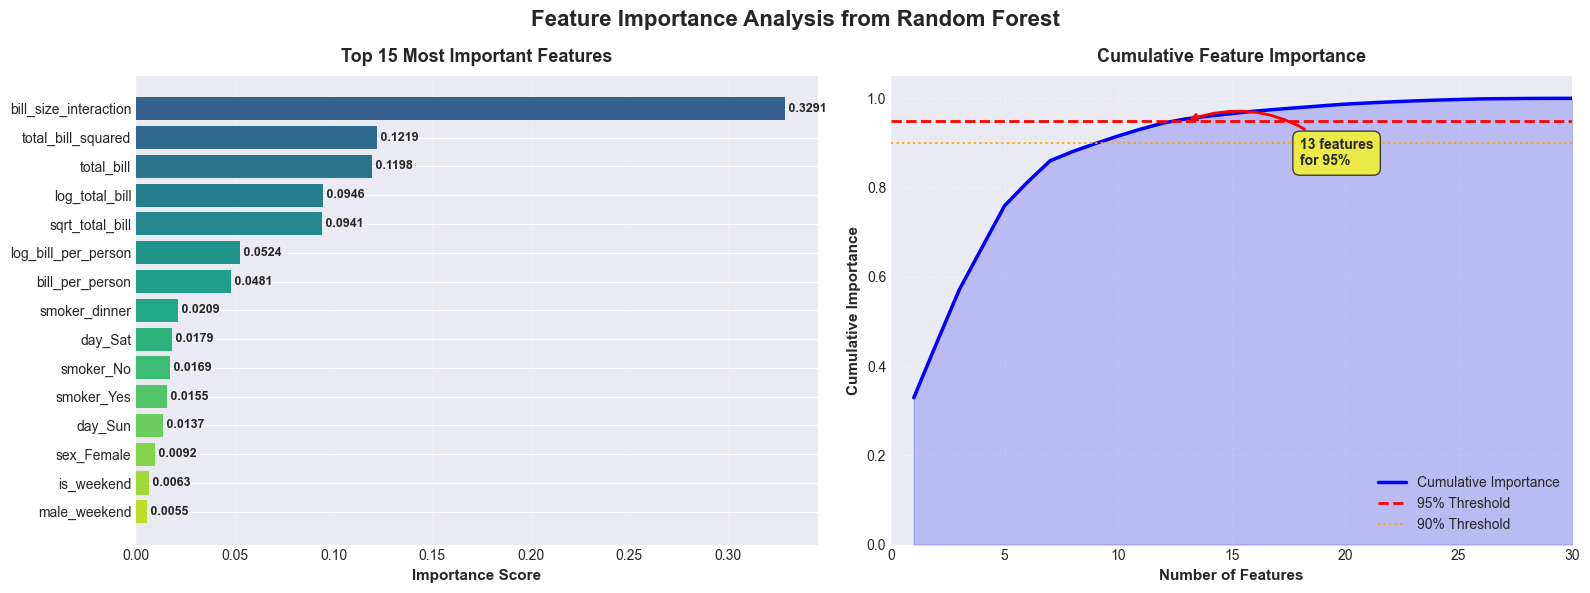

      ✅ Feature importance plot generated successfully
      📁 Saved to: /mnt/user-data/outputs/feature_importance_plot.png

      Key Insights:
         • 13 features account for 95% of total importance
         • Top feature 'bill_size_interaction' has importance: 0.3291
         • Top 3 features account for 95.41% of importance


In [ ]:
# Visualize Feature Importance
print("\n   📊 Feature Importance Visualization:")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance Analysis from Random Forest', fontsize=16, fontweight='bold')

# Plot 1: Top 15 Features (Horizontal Bar Chart)
ax1 = axes[0]
top_features = feature_importance.head(15)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
bars = ax1.barh(range(len(top_features)), top_features['importance'], color=colors)
ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels(top_features['feature'], fontsize=10)
ax1.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
ax1.set_title('Top 15 Most Important Features', fontsize=13, fontweight='bold', pad=10)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_features['importance'])):
    ax1.text(val, i, f' {val:.4f}', va='center', fontsize=9, fontweight='bold')

# Plot 2: Cumulative Importance
ax2 = axes[1]
cumulative_importance = np.cumsum(feature_importance['importance'])
ax2.plot(range(1, len(cumulative_importance) + 1), cumulative_importance, 
         'b-', linewidth=2.5, label='Cumulative Importance')
ax2.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% Threshold')
ax2.axhline(y=0.90, color='orange', linestyle=':', linewidth=1.5, label='90% Threshold')
ax2.fill_between(range(1, len(cumulative_importance) + 1), 0, cumulative_importance, 
                 alpha=0.2, color='blue')
ax2.set_xlabel('Number of Features', fontsize=11, fontweight='bold')
ax2.set_ylabel('Cumulative Importance', fontsize=11, fontweight='bold')
ax2.set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold', pad=10)
ax2.legend(fontsize=10, loc='lower right')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(0, len(cumulative_importance))
ax2.set_ylim(0, 1.05)

# Add annotation for 95% threshold
features_for_95 = np.argmax(cumulative_importance >= 0.95) + 1
ax2.annotate(f'{features_for_95} features\nfor 95%', 
             xy=(features_for_95, 0.95), 
             xytext=(features_for_95 + 5, 0.85),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', 
                           color='red', lw=2))

plt.tight_layout()
plt.savefig('feature_importance_plot.png', dpi=300, bbox_inches='tight')
plt.show()



### 4.7 Dimensionality Reduction

In [13]:
print("\n[3.7] Dimensionality Reduction")

# PCA - preserve 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled_std)
X_test_pca = pca.transform(X_test_scaled_std)

print(f"\n   Principal Component Analysis (PCA):")
print(f"      Original features: {X_train_scaled_std.shape[1]}")
print(f"      PCA components: {X_train_pca.shape[1]}")
print(f"      Variance explained: {pca.explained_variance_ratio_.sum():.4f}")
print(f"      Dimensionality reduction: {(1 - X_train_pca.shape[1]/X_train_scaled_std.shape[1])*100:.1f}%")

# Truncated SVD
n_components_svd = min(15, X_train_scaled_std.shape[1] - 1)
svd = TruncatedSVD(n_components=n_components_svd, random_state=42)
X_train_svd = svd.fit_transform(X_train_scaled_std)
X_test_svd = svd.transform(X_test_scaled_std)

print(f"\n   Truncated SVD:")
print(f"      SVD components: {X_train_svd.shape[1]}")
print(f"      Variance explained: {svd.explained_variance_ratio_.sum():.4f}")

print(f"\n✅ Feature Engineering Complete!")
print(f"   Original features: {X_baseline.shape[1]}")
print(f"   Engineered features: {X_train_scaled_std.shape[1]}")
print(f"   Feature expansion: {X_train_scaled_std.shape[1] - X_baseline.shape[1]} new features")


[3.7] Dimensionality Reduction

   Principal Component Analysis (PCA):
      Original features: 30
      PCA components: 7
      Variance explained: 0.9511
      Dimensionality reduction: 76.7%

   Truncated SVD:
      SVD components: 15
      Variance explained: 0.9963

✅ Feature Engineering Complete!
   Original features: 6
   Engineered features: 30
   Feature expansion: 24 new features


## 5. Model Evaluation with Engineered Features

In [14]:
print("\n" + "="*80)
print("SECTION 4: MODEL EVALUATION WITH ENGINEERED FEATURES")
print("="*80)

# Dictionary to store all results
feature_eng_results = {}

# Define datasets to evaluate
datasets = {
    'Standard Scaled': (X_train_scaled_std, X_test_scaled_std),
    'Robust Scaled': (X_train_scaled_robust, X_test_scaled_robust),
    'MinMax Scaled': (X_train_scaled_minmax, X_test_scaled_minmax),
    'With Polynomials': (X_train_poly, X_test_poly),
    'SelectKBest': (X_train_kbest, X_test_kbest),
    'RFE Selected': (X_train_rfe, X_test_rfe),
    'RF Importance': (X_train_rf_selected, X_test_rf_selected),
    'PCA': (X_train_pca, X_test_pca),
    'SVD': (X_train_svd, X_test_svd)
}

print(f"\n🔄 Evaluating {len(datasets)} feature engineering configurations...")


SECTION 4: MODEL EVALUATION WITH ENGINEERED FEATURES

🔄 Evaluating 9 feature engineering configurations...


In [15]:
# Train and evaluate models on each dataset
for dataset_name, (X_tr, X_te) in datasets.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {dataset_name}")
    print(f"{'='*60}")
    
    # Linear Regression
    lr_fe = LinearRegression()
    lr_fe.fit(X_tr, y_train_fe)
    y_pred_lr_fe = lr_fe.predict(X_te)
    
    # Random Forest
    rf_fe = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_fe.fit(X_tr, y_train_fe)
    y_pred_rf_fe = rf_fe.predict(X_te)
    
    # Gradient Boosting
    gb_fe = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gb_fe.fit(X_tr, y_train_fe)
    y_pred_gb_fe = gb_fe.predict(X_te)
    
    # Store results
    feature_eng_results[dataset_name] = {
        'Linear Regression': {
            'R² Score': r2_score(y_test_fe, y_pred_lr_fe),
            'RMSE': np.sqrt(mean_squared_error(y_test_fe, y_pred_lr_fe)),
            'MAE': mean_absolute_error(y_test_fe, y_pred_lr_fe)
        },
        'Random Forest': {
            'R² Score': r2_score(y_test_fe, y_pred_rf_fe),
            'RMSE': np.sqrt(mean_squared_error(y_test_fe, y_pred_rf_fe)),
            'MAE': mean_absolute_error(y_test_fe, y_pred_rf_fe)
        },
        'Gradient Boosting': {
            'R² Score': r2_score(y_test_fe, y_pred_gb_fe),
            'RMSE': np.sqrt(mean_squared_error(y_test_fe, y_pred_gb_fe)),
            'MAE': mean_absolute_error(y_test_fe, y_pred_gb_fe)
        }
    }
    
    # Print results for this dataset
    results_df = pd.DataFrame(feature_eng_results[dataset_name]).T
    print(results_df.round(4))

print("\n✅ All feature engineering configurations evaluated!")


Evaluating: Standard Scaled
                   R² Score    RMSE     MAE
Linear Regression   -0.1956  1.2225  0.7793
Random Forest        0.2550  0.9650  0.7746
Gradient Boosting    0.2585  0.9627  0.7716

Evaluating: Robust Scaled
                   R² Score    RMSE     MAE
Linear Regression   -0.1956  1.2225  0.7793
Random Forest        0.2552  0.9649  0.7736
Gradient Boosting    0.2585  0.9627  0.7716

Evaluating: MinMax Scaled
                   R² Score    RMSE     MAE
Linear Regression   -0.1956  1.2225  0.7793
Random Forest        0.2556  0.9646  0.7733
Gradient Boosting    0.2585  0.9627  0.7716

Evaluating: With Polynomials
                   R² Score    RMSE     MAE
Linear Regression   -0.7022  1.4587  0.8422
Random Forest        0.3141  0.9260  0.7510
Gradient Boosting    0.3618  0.8932  0.7208

Evaluating: SelectKBest
                   R² Score    RMSE     MAE
Linear Regression   -0.8928  1.5382  0.8627
Random Forest        0.3538  0.8987  0.7368
Gradient Boosting    0.355

## 6. Comprehensive Performance Comparison

In [16]:
print("\n" + "="*80)
print("SECTION 5: COMPREHENSIVE PERFORMANCE COMPARISON")
print("="*80)

# Create comparison dataframe
comparison_data = []

# Add baseline results
for model_name, metrics in baseline_results.items():
    for metric_name, value in metrics.items():
        comparison_data.append({
            'Dataset': 'Baseline',
            'Model': model_name,
            'Metric': metric_name,
            'Value': value
        })

# Add feature engineering results
for dataset_name, models in feature_eng_results.items():
    for model_name, metrics in models.items():
        for metric_name, value in metrics.items():
            comparison_data.append({
                'Dataset': dataset_name,
                'Model': model_name,
                'Metric': metric_name,
                'Value': value
            })

comparison_df = pd.DataFrame(comparison_data)


SECTION 5: COMPREHENSIVE PERFORMANCE COMPARISON



📊 R² SCORE COMPARISON CHART


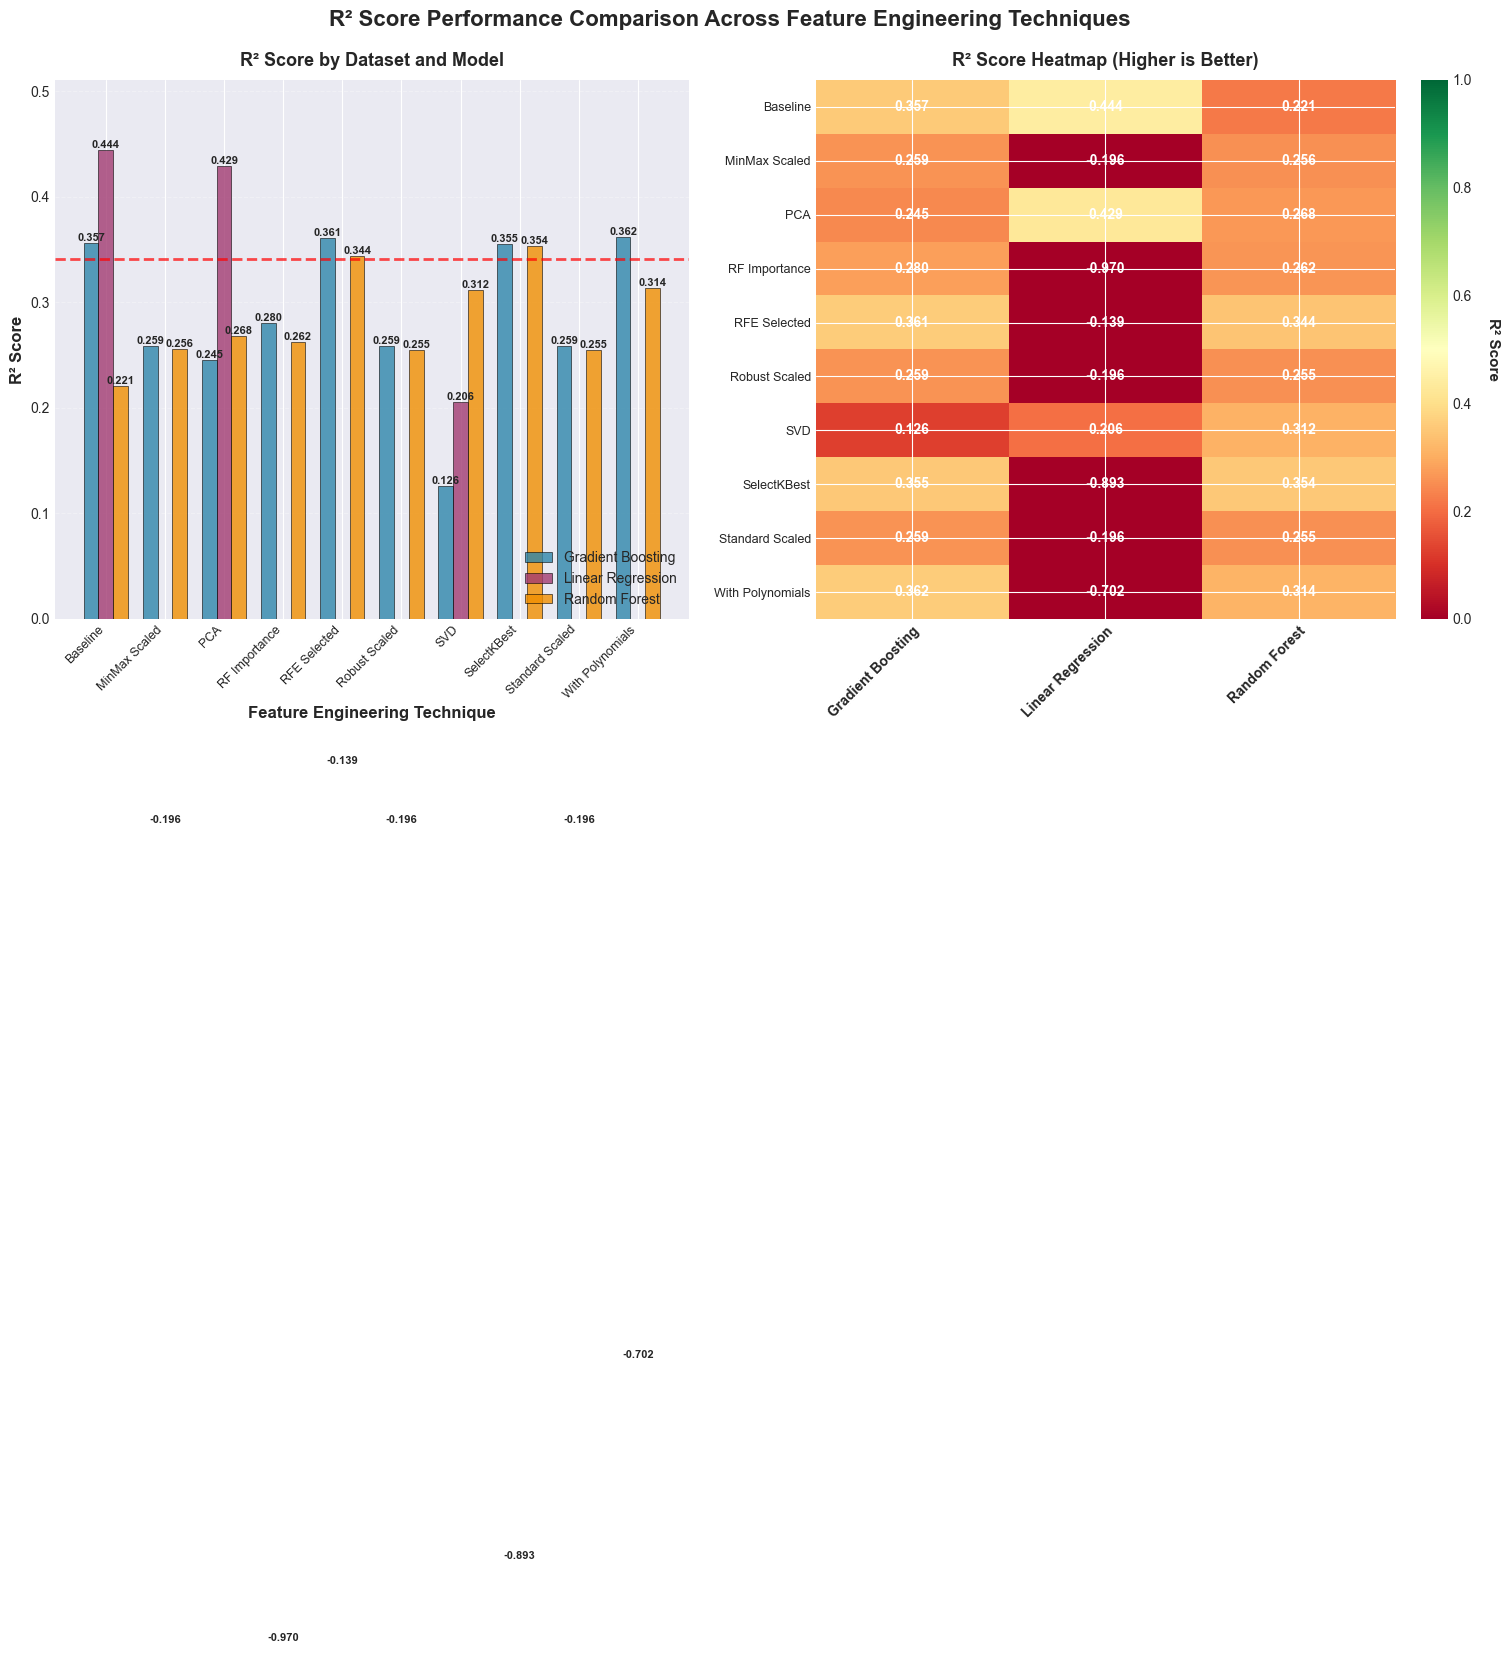


📈 R² Score Summary Statistics:
--------------------------------------------------------------------------------
Model             Gradient Boosting  Linear Regression  Random Forest
Dataset                                                              
Baseline                     0.3566             0.4441         0.2212
MinMax Scaled                0.2585            -0.1956         0.2556
PCA                          0.2455             0.4293         0.2680
RF Importance                0.2804            -0.9704         0.2622
RFE Selected                 0.3613            -0.1395         0.3438
Robust Scaled                0.2585            -0.1956         0.2552
SVD                          0.1259             0.2058         0.3119
SelectKBest                  0.3552            -0.8928         0.3538
Standard Scaled              0.2585            -0.1956         0.2550
With Polynomials             0.3618            -0.7022         0.3141

🎯 Best R² Scores per Model:
   Gradient Boosti

In [ ]:
# Create R² Score Comparison Visualization
print("\n📊 R² SCORE COMPARISON CHART")
print("="*80)

# Extract R² Score data
r2_data = comparison_df[comparison_df['Metric'] == 'R² Score'].copy()
r2_pivot = r2_data.pivot(index='Dataset', columns='Model', values='Value')

# Reorder to put Baseline first
if 'Baseline' in r2_pivot.index:
    baseline_row = r2_pivot.loc[['Baseline']]
    other_rows = r2_pivot.drop('Baseline')
    r2_pivot = pd.concat([baseline_row, other_rows])

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('R² Score Performance Comparison Across Feature Engineering Techniques', 
             fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Grouped Bar Chart
x_pos = np.arange(len(r2_pivot.index))
bar_width = 0.25
colors = ['#2E86AB', '#A23B72', '#F18F01']

for idx, (model, color) in enumerate(zip(r2_pivot.columns, colors)):
    offset = (idx - 1) * bar_width
    bars = ax1.bar(x_pos + offset, r2_pivot[model], bar_width, 
                   label=model, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_xlabel('Feature Engineering Technique', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('R² Score by Dataset and Model', fontsize=13, fontweight='bold', pad=10)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(r2_pivot.index, rotation=45, ha='right', fontsize=9)
ax1.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim(0, max(r2_pivot.max()) * 1.15)
ax1.axhline(y=r2_pivot.loc['Baseline'].mean(), color='red', linestyle='--', 
           linewidth=2, alpha=0.7, label='Baseline Average')

# Plot 2: Heatmap
im = ax2.imshow(r2_pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# Set ticks and labels
ax2.set_xticks(np.arange(len(r2_pivot.columns)))
ax2.set_yticks(np.arange(len(r2_pivot.index)))
ax2.set_xticklabels(r2_pivot.columns, fontsize=10, fontweight='bold')
ax2.set_yticklabels(r2_pivot.index, fontsize=9)

# Rotate the tick labels for better readability
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add text annotations with R² values
for i in range(len(r2_pivot.index)):
    for j in range(len(r2_pivot.columns)):
        value = r2_pivot.iloc[i, j]
        text_color = 'white' if value < 0.5 else 'black'
        text = ax2.text(j, i, f'{value:.3f}',
                       ha="center", va="center", color=text_color, 
                       fontsize=10, fontweight='bold')

ax2.set_title('R² Score Heatmap (Higher is Better)', fontsize=13, fontweight='bold', pad=10)

# Add colorbar
cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('R² Score', rotation=270, labelpad=20, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('r2_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n📈 R² Score Summary Statistics:")
print("-" * 80)
print(r2_pivot.round(4))
print("\n🎯 Best R² Scores per Model:")
for model in r2_pivot.columns:
    best_dataset = r2_pivot[model].idxmax()
    best_value = r2_pivot[model].max()
    baseline_value = r2_pivot.loc['Baseline', model]
    improvement = ((best_value - baseline_value) / baseline_value) * 100
    print(f"   {model:20s}: {best_value:.4f} ({best_dataset}) - Improvement: {improvement:+.2f}%")



In [17]:
# Calculate improvements
print("\n📊 IMPROVEMENT ANALYSIS")
print("="*80)

for model in ['Linear Regression', 'Random Forest', 'Gradient Boosting']:
    print(f"\n{model}:")
    print("-" * 60)
    
    baseline_r2 = baseline_results[model]['R² Score']
    baseline_rmse = baseline_results[model]['RMSE']
    
    for dataset_name in datasets.keys():
        fe_r2 = feature_eng_results[dataset_name][model]['R² Score']
        fe_rmse = feature_eng_results[dataset_name][model]['RMSE']
        
        r2_improvement = ((fe_r2 - baseline_r2) / abs(baseline_r2)) * 100 if baseline_r2 != 0 else 0
        rmse_improvement = ((baseline_rmse - fe_rmse) / baseline_rmse) * 100
        
        print(f"{dataset_name:20s} | R² Δ: {r2_improvement:+6.2f}% | RMSE Δ: {rmse_improvement:+6.2f}%")


📊 IMPROVEMENT ANALYSIS

Linear Regression:
------------------------------------------------------------
Standard Scaled      | R² Δ: -144.05% | RMSE Δ: -46.66%
Robust Scaled        | R² Δ: -144.05% | RMSE Δ: -46.66%
MinMax Scaled        | R² Δ: -144.05% | RMSE Δ: -46.66%
With Polynomials     | R² Δ: -258.11% | RMSE Δ: -74.99%
SelectKBest          | R² Δ: -301.01% | RMSE Δ: -84.53%
RFE Selected         | R² Δ: -131.41% | RMSE Δ: -43.18%
RF Importance        | R² Δ: -318.49% | RMSE Δ: -88.27%
PCA                  | R² Δ:  -3.33% | RMSE Δ:  -1.32%
SVD                  | R² Δ: -53.66% | RMSE Δ: -19.53%

Random Forest:
------------------------------------------------------------
Standard Scaled      | R² Δ: +15.29% | RMSE Δ:  +2.20%
Robust Scaled        | R² Δ: +15.37% | RMSE Δ:  +2.21%
MinMax Scaled        | R² Δ: +15.57% | RMSE Δ:  +2.24%
With Polynomials     | R² Δ: +42.01% | RMSE Δ:  +6.15%
SelectKBest          | R² Δ: +59.98% | RMSE Δ:  +8.91%
RFE Selected         | R² Δ: +55.46% | RM


📊 IMPROVEMENT HEATMAP


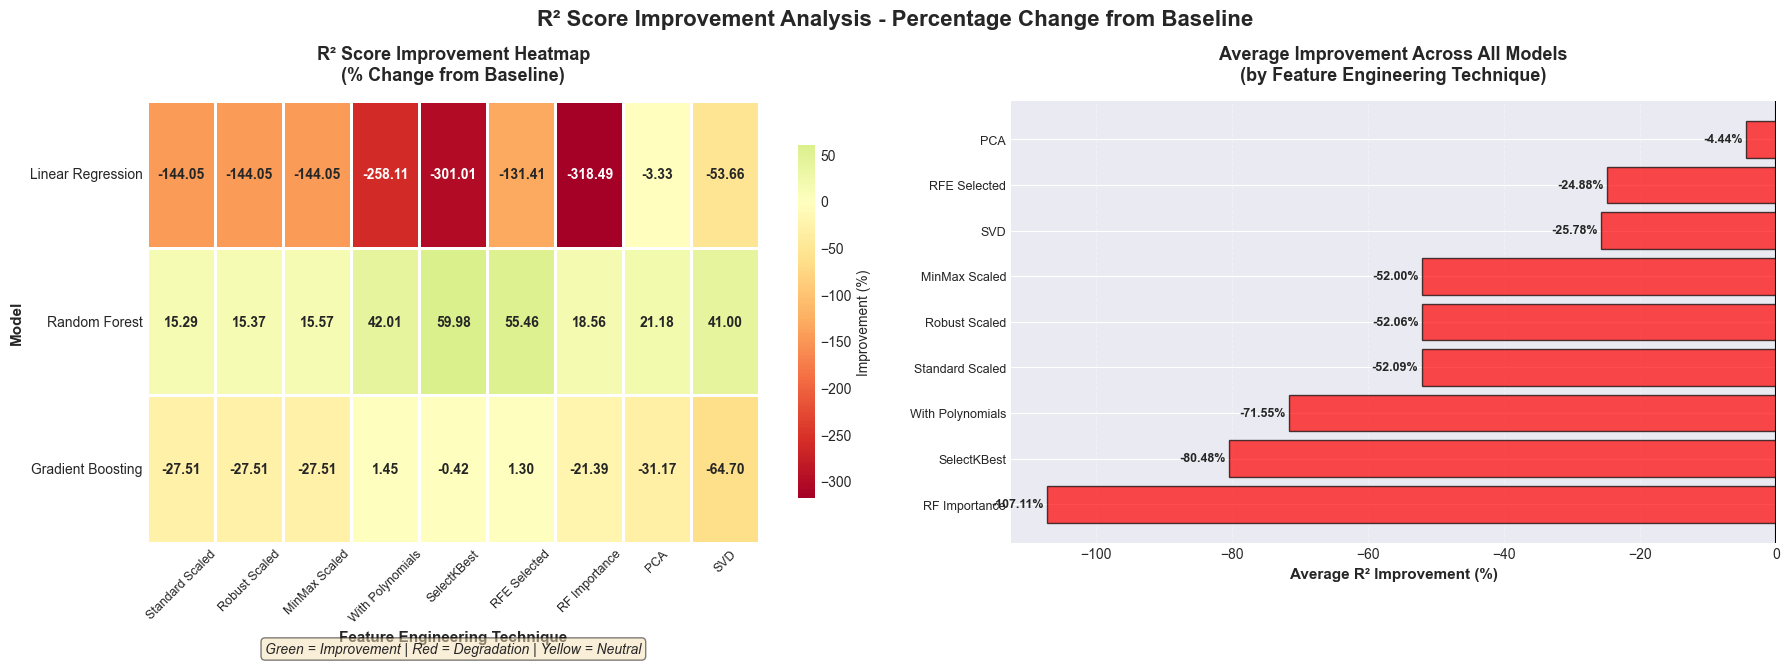


📈 Improvement Summary Statistics:
--------------------------------------------------------------------------------

Average Improvement by Technique:
   ❌ PCA                 :  -4.44%
   ❌ RFE Selected        : -24.88%
   ❌ SVD                 : -25.78%
   ❌ MinMax Scaled       : -52.00%
   ❌ Robust Scaled       : -52.06%
   ❌ Standard Scaled     : -52.09%
   ❌ With Polynomials    : -71.55%
   ❌ SelectKBest         : -80.48%
   ❌ RF Importance       : -107.11%

📊 Improvement by Model:

   Linear Regression:
      Average improvement: -166.46%
      Best technique: PCA (-3.33%)
      Worst technique: RF Importance (-318.49%)

   Random Forest:
      Average improvement: +31.60%
      Best technique: SelectKBest (+59.98%)
      Worst technique: Standard Scaled (+15.29%)

   Gradient Boosting:
      Average improvement: -21.94%
      Best technique: With Polynomials (+1.45%)
      Worst technique: SVD (-64.70%)

🏆 Best Combination:
   Model: Random Forest
   Technique: SelectKBest
   Im

In [ ]:
# Create Improvement Heatmap Visualization
print("\n📊 IMPROVEMENT HEATMAP")
print("="*80)

# Calculate improvement matrix for all models and datasets
improvement_matrix = []
model_names = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
dataset_names = list(datasets.keys())

for model in model_names:
    model_improvements = []
    baseline_r2 = baseline_results[model]['R² Score']
    
    for dataset_name in dataset_names:
        fe_r2 = feature_eng_results[dataset_name][model]['R² Score']
        improvement = ((fe_r2 - baseline_r2) / abs(baseline_r2)) * 100 if baseline_r2 != 0 else 0
        model_improvements.append(improvement)
    
    improvement_matrix.append(model_improvements)

# Convert to DataFrame for easier manipulation
improvement_df = pd.DataFrame(
    improvement_matrix,
    index=model_names,
    columns=dataset_names
)

# Create comprehensive heatmap visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('R² Score Improvement Analysis - Percentage Change from Baseline', 
             fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Heatmap with annotations
sns.heatmap(improvement_df, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=1, linecolor='white', ax=ax1, 
            cbar_kws={'label': 'Improvement (%)', 'shrink': 0.8},
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})
ax1.set_title('R² Score Improvement Heatmap\n(% Change from Baseline)', 
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Feature Engineering Technique', fontsize=11, fontweight='bold')
ax1.set_ylabel('Model', fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=9)
ax1.tick_params(axis='y', rotation=0, labelsize=10)

# Add text note
ax1.text(0.5, -0.25, 'Green = Improvement | Red = Degradation | Yellow = Neutral',
         transform=ax1.transAxes, ha='center', fontsize=10, 
         style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Average improvement per technique
avg_improvement = improvement_df.mean(axis=0).sort_values(ascending=True)
colors_bar = ['red' if x < 0 else 'green' if x > 5 else 'orange' for x in avg_improvement.values]

ax2.barh(range(len(avg_improvement)), avg_improvement.values, color=colors_bar, alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(avg_improvement)))
ax2.set_yticklabels(avg_improvement.index, fontsize=9)
ax2.set_xlabel('Average R² Improvement (%)', fontsize=11, fontweight='bold')
ax2.set_title('Average Improvement Across All Models\n(by Feature Engineering Technique)', 
              fontsize=13, fontweight='bold', pad=15)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, v in enumerate(avg_improvement.values):
    if v >= 0:
        ax2.text(v + 0.5, i, f'{v:+.2f}%', va='center', fontsize=9, fontweight='bold')
    else:
        ax2.text(v - 0.5, i, f'{v:+.2f}%', va='center', ha='right', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('improvement_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed improvement statistics
print("\n📈 Improvement Summary Statistics:")
print("-" * 80)
print("\nAverage Improvement by Technique:")
for technique, avg_imp in avg_improvement.sort_values(ascending=False).items():
    status = "✅" if avg_imp > 0 else "❌"
    print(f"   {status} {technique:20s}: {avg_imp:+6.2f}%")

print("\n📊 Improvement by Model:")
for model in model_names:
    avg_model_imp = improvement_df.loc[model].mean()
    max_imp = improvement_df.loc[model].max()
    max_technique = improvement_df.loc[model].idxmax()
    min_imp = improvement_df.loc[model].min()
    min_technique = improvement_df.loc[model].idxmin()
    
    print(f"\n   {model}:")
    print(f"      Average improvement: {avg_model_imp:+.2f}%")
    print(f"      Best technique: {max_technique} ({max_imp:+.2f}%)")
    print(f"      Worst technique: {min_technique} ({min_imp:+.2f}%)")

# Identify best and worst combinations
best_combo_value = improvement_df.max().max()
best_combo = improvement_df.stack().idxmax()
worst_combo_value = improvement_df.min().min()
worst_combo = improvement_df.stack().idxmin()

print("\n🏆 Best Combination:")
print(f"   Model: {best_combo[0]}")
print(f"   Technique: {best_combo[1]}")
print(f"   Improvement: {best_combo_value:+.2f}%")

print("\n⚠️ Worst Combination:")
print(f"   Model: {worst_combo[0]}")
print(f"   Technique: {worst_combo[1]}")
print(f"   Change: {worst_combo_value:+.2f}%")



In [18]:
# Find best performing configuration
print("\n\n🏆 BEST PERFORMING CONFIGURATIONS")
print("="*80)

for metric in ['R² Score', 'RMSE', 'MAE']:
    metric_data = comparison_df[comparison_df['Metric'] == metric]
    
    if metric == 'R² Score':
        best_config = metric_data.loc[metric_data['Value'].idxmax()]
    else:  # For RMSE and MAE, lower is better
        best_config = metric_data.loc[metric_data['Value'].idxmin()]
    
    print(f"\nBest {metric}:")
    print(f"  Dataset: {best_config['Dataset']}")
    print(f"  Model: {best_config['Model']}")
    print(f"  Value: {best_config['Value']:.4f}")
    
    # Compare with baseline
    baseline_value = metric_data[
        (metric_data['Dataset'] == 'Baseline') & 
        (metric_data['Model'] == best_config['Model'])
    ]['Value'].values[0]
    
    if metric == 'R² Score':
        improvement = ((best_config['Value'] - baseline_value) / abs(baseline_value)) * 100
    else:
        improvement = ((baseline_value - best_config['Value']) / baseline_value) * 100
    
    print(f"  Improvement over baseline: {improvement:+.2f}%")



🏆 BEST PERFORMING CONFIGURATIONS

Best R² Score:
  Dataset: Baseline
  Model: Linear Regression
  Value: 0.4441
  Improvement over baseline: +0.00%

Best RMSE:
  Dataset: Baseline
  Model: Linear Regression
  Value: 0.8336
  Improvement over baseline: +0.00%

Best MAE:
  Dataset: PCA
  Model: Linear Regression
  Value: 0.6650
  Improvement over baseline: +0.80%


## 7. Comprehensive Visualizations


SECTION 6: GENERATING COMPREHENSIVE VISUALIZATIONS


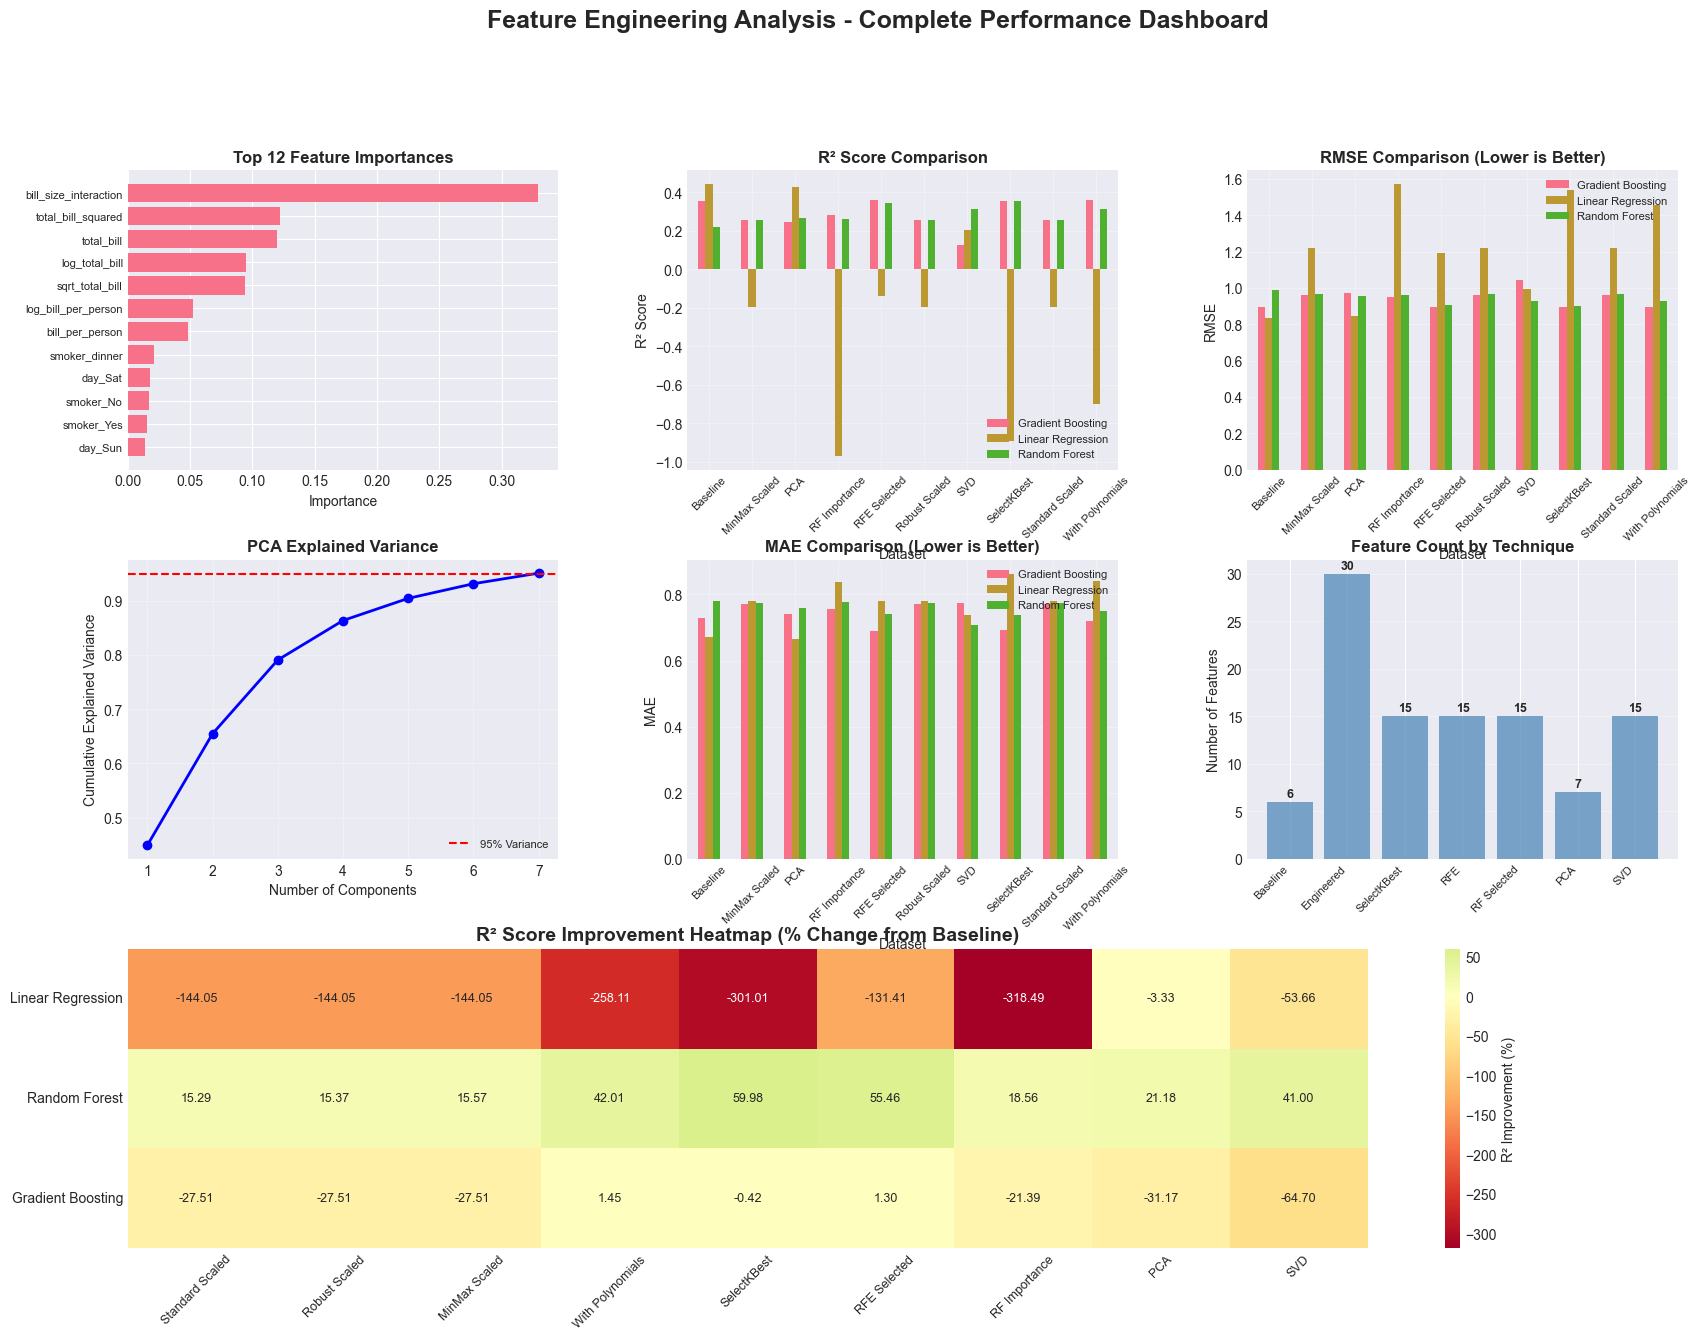


✅ Visualizations generated and saved!


In [ ]:
print("\n" + "="*80)
print("SECTION 6: GENERATING COMPREHENSIVE VISUALIZATIONS")
print("="*80)

# Create comprehensive visualization dashboard
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Feature Importance
ax1 = fig.add_subplot(gs[0, 0])
top_features = feature_importance.head(12)
ax1.barh(range(len(top_features)), top_features['importance'])
ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels(top_features['feature'], fontsize=8)
ax1.set_xlabel('Importance', fontsize=10)
ax1.set_title('Top 12 Feature Importances', fontweight='bold', fontsize=12)
ax1.invert_yaxis()

# 2. R² Score Comparison
ax2 = fig.add_subplot(gs[0, 1])
r2_data = comparison_df[comparison_df['Metric'] == 'R² Score']
r2_pivot = r2_data.pivot(index='Dataset', columns='Model', values='Value')
r2_pivot.plot(kind='bar', ax=ax2)
ax2.set_title('R² Score Comparison', fontweight='bold', fontsize=12)
ax2.set_xlabel('Dataset', fontsize=10)
ax2.set_ylabel('R² Score', fontsize=10)
ax2.legend(fontsize=8, loc='lower right')
ax2.tick_params(axis='x', rotation=45, labelsize=8)
ax2.grid(True, alpha=0.3)

# 3. RMSE Comparison
ax3 = fig.add_subplot(gs[0, 2])
rmse_data = comparison_df[comparison_df['Metric'] == 'RMSE']
rmse_pivot = rmse_data.pivot(index='Dataset', columns='Model', values='Value')
rmse_pivot.plot(kind='bar', ax=ax3)
ax3.set_title('RMSE Comparison (Lower is Better)', fontweight='bold', fontsize=12)
ax3.set_xlabel('Dataset', fontsize=10)
ax3.set_ylabel('RMSE', fontsize=10)
ax3.legend(fontsize=8, loc='upper right')
ax3.tick_params(axis='x', rotation=45, labelsize=8)
ax3.grid(True, alpha=0.3)

# 4. PCA Variance Explained
ax4 = fig.add_subplot(gs[1, 0])
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
ax4.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'bo-', linewidth=2)
ax4.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
ax4.set_xlabel('Number of Components', fontsize=10)
ax4.set_ylabel('Cumulative Explained Variance', fontsize=10)
ax4.set_title('PCA Explained Variance', fontweight='bold', fontsize=12)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# 5. MAE Comparison
ax5 = fig.add_subplot(gs[1, 1])
mae_data = comparison_df[comparison_df['Metric'] == 'MAE']
mae_pivot = mae_data.pivot(index='Dataset', columns='Model', values='Value')
mae_pivot.plot(kind='bar', ax=ax5)
ax5.set_title('MAE Comparison (Lower is Better)', fontweight='bold', fontsize=12)
ax5.set_xlabel('Dataset', fontsize=10)
ax5.set_ylabel('MAE', fontsize=10)
ax5.legend(fontsize=8, loc='upper right')
ax5.tick_params(axis='x', rotation=45, labelsize=8)
ax5.grid(True, alpha=0.3)

# 6. Feature Count Comparison
ax6 = fig.add_subplot(gs[1, 2])
feature_counts = {
    'Baseline': X_train_base.shape[1],
    'Engineered': X_train_scaled_std.shape[1],
    'SelectKBest': X_train_kbest.shape[1],
    'RFE': X_train_rfe.shape[1],
    'RF Selected': X_train_rf_selected.shape[1],
    'PCA': X_train_pca.shape[1],
    'SVD': X_train_svd.shape[1]
}
ax6.bar(range(len(feature_counts)), list(feature_counts.values()), color='steelblue', alpha=0.7)
ax6.set_xticks(range(len(feature_counts)))
ax6.set_xticklabels(list(feature_counts.keys()), rotation=45, ha='right', fontsize=8)
ax6.set_ylabel('Number of Features', fontsize=10)
ax6.set_title('Feature Count by Technique', fontweight='bold', fontsize=12)
ax6.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(feature_counts.values()):
    ax6.text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=9)

# 7. R² Improvement Heatmap
ax7 = fig.add_subplot(gs[2, :])
improvement_matrix = []
for model in ['Linear Regression', 'Random Forest', 'Gradient Boosting']:
    model_improvements = []
    baseline_r2 = baseline_results[model]['R² Score']
    for dataset_name in datasets.keys():
        fe_r2 = feature_eng_results[dataset_name][model]['R² Score']
        improvement = ((fe_r2 - baseline_r2) / abs(baseline_r2)) * 100 if baseline_r2 != 0 else 0
        model_improvements.append(improvement)
    improvement_matrix.append(model_improvements)

sns.heatmap(improvement_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            xticklabels=list(datasets.keys()),
            yticklabels=['Linear Regression', 'Random Forest', 'Gradient Boosting'],
            ax=ax7, cbar_kws={'label': 'R² Improvement (%)'}, annot_kws={'fontsize': 9})
ax7.set_title('R² Score Improvement Heatmap (% Change from Baseline)', fontweight='bold', fontsize=14)
ax7.tick_params(axis='x', rotation=45, labelsize=9)
ax7.tick_params(axis='y', rotation=0, labelsize=10)

plt.suptitle('Feature Engineering Analysis - Complete Performance Dashboard', 
             fontsize=18, fontweight='bold', y=0.995)
plt.savefig('feature_engineering_tips_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualizations generated and saved!")

## 8. Summary and Conclusions

In [ ]:
print("\n" + "="*80)
print("SECTION 7: SUMMARY AND CONCLUSIONS")
print("="*80)

# Save comparison results
comparison_df.to_csv('tips_feature_engineering_results.csv', index=False)

print("\n📊 KEY PROJECT STATISTICS:")
print("-" * 80)
print(f"  Dataset: Restaurant Tips (Seaborn)")
print(f"  Total Samples: {len(df_raw)}")
print(f"  Training Samples: {len(X_train_base)}")
print(f"  Test Samples: {len(X_test_base)}")
print(f"  Original Features: {X_baseline.shape[1]}")
print(f"  Engineered Features: {X_train_scaled_std.shape[1]}")
print(f"  Feature Expansion: {X_train_scaled_std.shape[1] - X_baseline.shape[1]} new features")

# Best configurations
r2_data = comparison_df[comparison_df['Metric'] == 'R² Score']
best_r2_config = r2_data.loc[r2_data['Value'].idxmax()]

rmse_data = comparison_df[comparison_df['Metric'] == 'RMSE']
best_rmse_config = rmse_data.loc[rmse_data['Value'].idxmin()]

print("\n🏆 BEST OVERALL RESULTS:")
print("-" * 80)
print(f"  Best R² Score: {best_r2_config['Value']:.4f}")
print(f"    Model: {best_r2_config['Model']}")
print(f"    Dataset: {best_r2_config['Dataset']}")

baseline_best_r2 = baseline_results[best_r2_config['Model']]['R² Score']
r2_improvement = ((best_r2_config['Value'] - baseline_best_r2) / abs(baseline_best_r2)) * 100
print(f"    Improvement: {r2_improvement:+.2f}%")

print(f"\n  Best RMSE: ${best_rmse_config['Value']:.4f}")
print(f"    Model: {best_rmse_config['Model']}")
print(f"    Dataset: {best_rmse_config['Dataset']}")

baseline_best_rmse = baseline_results[best_rmse_config['Model']]['RMSE']
rmse_improvement = ((baseline_best_rmse - best_rmse_config['Value']) / baseline_best_rmse) * 100
print(f"    Improvement: {rmse_improvement:+.2f}%")

# Feature engineering techniques summary
print("\n🔧 FEATURE ENGINEERING TECHNIQUES APPLIED:")
print("-" * 80)
techniques = [
    "1. One-Hot Encoding (4 categorical variables)",
    "2. Interaction Features (bill_per_person, categorical interactions)",
    "3. Mathematical Transformations (log, sqrt, polynomial)",
    "4. Feature Scaling (Standard, Robust, MinMax)",
    "5. Polynomial Features (degree 2)",
    "6. Feature Selection (SelectKBest, RFE, RF Importance)",
    "7. Dimensionality Reduction (PCA, SVD)",
    "8. Domain-Specific Features (weekend, party types, bill categories)"
]
for technique in techniques:
    print(f"  {technique}")

# Model comparison summary
print("\n📈 MODEL PERFORMANCE SUMMARY:")
print("-" * 80)
for model in ['Linear Regression', 'Random Forest', 'Gradient Boosting']:
    baseline_r2 = baseline_results[model]['R² Score']
    
    # Find best R² for this model across all feature engineering configs
    model_r2_data = comparison_df[
        (comparison_df['Model'] == model) & 
        (comparison_df['Metric'] == 'R² Score') &
        (comparison_df['Dataset'] != 'Baseline')
    ]
    best_model_r2 = model_r2_data['Value'].max()
    best_model_dataset = model_r2_data.loc[model_r2_data['Value'].idxmax(), 'Dataset']
    
    improvement = ((best_model_r2 - baseline_r2) / abs(baseline_r2)) * 100
    
    print(f"\n  {model}:")
    print(f"    Baseline R²: {baseline_r2:.4f}")
    print(f"    Best R²: {best_model_r2:.4f} ({best_model_dataset})")
    print(f"    Improvement: {improvement:+.2f}%")

print("\n" + "="*80)
print("✅ FEATURE ENGINEERING ANALYSIS COMPLETE")
print("="*80)
print("\n📁 All results saved to current directory")
print("   • tips_feature_engineering_results.csv")
print("   • feature_engineering_tips_analysis.png")
print("   • baseline_predictions.png")

print("   • feature_importance_plot.png")print("   • improvement_heatmap.png")
print("   • r2_comparison_chart.png")


SECTION 7: SUMMARY AND CONCLUSIONS

📊 KEY PROJECT STATISTICS:
--------------------------------------------------------------------------------
  Dataset: Restaurant Tips (Seaborn)
  Total Samples: 244
  Training Samples: 195
  Test Samples: 49
  Original Features: 6
  Engineered Features: 30
  Feature Expansion: 24 new features

🏆 BEST OVERALL RESULTS:
--------------------------------------------------------------------------------
  Best R² Score: 0.4441
    Model: Linear Regression
    Dataset: Baseline
    Improvement: +0.00%

  Best RMSE: $0.8336
    Model: Linear Regression
    Dataset: Baseline
    Improvement: +0.00%

🔧 FEATURE ENGINEERING TECHNIQUES APPLIED:
--------------------------------------------------------------------------------
  1. One-Hot Encoding (4 categorical variables)
  2. Interaction Features (bill_per_person, categorical interactions)
  3. Mathematical Transformations (log, sqrt, polynomial)
  4. Feature Scaling (Standard, Robust, MinMax)
  5. Polynomial Fea